<a href="https://colab.research.google.com/github/kaew878/Bangkok-condo-price-predict/blob/main/Predicting_Bangkok_Housing_Prices_by_Me!!!.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. นำเข้าข้อมูลและตรวจสอบ NaN Null**

In [1]:
import sys
# อัปเกรด XGBoost เป็นเวอร์ชันล่าสุด
!pip install xgboost -U -q

# Core
import numpy as np
import pandas as pd
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split as tts
from sklearn.metrics import r2_score as r2, mean_absolute_error as mae, mean_squared_error as mse
import warnings
warnings.filterwarnings('ignore')

print(f"XGBoost version: {xgb.__version__}")

XGBoost version: 3.2.0


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("thedevastator/predicting-bangkok-condominium-prices-using-web")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'predicting-bangkok-condominium-prices-using-web' dataset.
Path to dataset files: /kaggle/input/predicting-bangkok-condominium-prices-using-web


In [3]:
import os

# List the files in the downloaded dataset path
files = os.listdir(path)
print("Files in the dataset directory:", files)

Files in the dataset directory: ['GBoost_best_feature_importances_.csv', 'df_700.csv', 'df_cleaned.csv', 'ridge_coef.csv', 'df_900.csv', 'rf_best_feature_importances_.csv', 'df_0.csv', 'df_200.csv', 'df_300.csv', 'df_400.csv', 'df_600.csv', 'df_800.csv', 'ridge_result.csv', 'df_500.csv', 'df_cleaned_for_ML_regression.csv', 'df_completed.csv', 'df_100.csv', 'df_1000.csv', 'df_1018.csv']


In [4]:
# Assuming the main data file is 'df_cleaned.csv' based on the listed files
# Adjust the filename if it's different based on the output of the previous cell
data_file = os.path.join(path, 'df_cleaned_for_ML_regression.csv')

# Load the data into a pandas DataFrame
df = pd.read_csv(data_file)

# Display the first 5 rows of the DataFrame
display(df.head())
df.shape

,name,district,latitude,longitude,year_built,proj_area,nbr_buildings,nbr_floors,units,hospital,...,tran_name1,tran_name2,tran_name3,tran_name4,tran_name5,dist_tran_1,dist_tran_2,dist_tran_3,dist_tran_4,dist_tran_5
0,101 Mansion,Bang Kapi,13.787435,100.631564,1991,23371,5,5,834.0,2.10,...,Lat Phrao Toll Plaza,Yothin Phatthana Toll Plaza,Pracha Uthit Toll Plaza,Sutthisan,Huai Khwang,4.3,4.8,5.0,8.1,8.3
1,624 Condolette Ladprao,Bang Kapi,13.766348,100.649395,2011,6476,2,8,471.0,1.80,...,Lat Phrao Toll Plaza,Srinagarindra Toll Plaza,Pracha Uthit Toll Plaza,Huai Khwang,Thailand Cultural Centre,5.8,6.2,6.5,9.8,9.9
2,Adamas Ramkhamhaeng,Bang Kapi,13.752448,100.615507,1995,4699,1,16,140.0,2.30,...,Srinagarindra Toll Plaza,Ramkhamhaeng Toll Plaza,Phatthanakan 2 Toll Plaza,Phra Khanong,Ekkamai,2.1,2.5,2.9,6.1,6.3
3,Aspire Ladprao 113,Bang Kapi,13.770286,100.638799,2016,3816,1,8,270.0,0.68,...,Lat Phrao Toll Plaza,Pracha Uthit Toll Plaza,Srinagarindra Toll Plaza,Sutthisan,Huai Khwang,4.7,5.4,6.1,8.5,8.7
4,B.R. Condo,Bang Kapi,13.768706,100.638876,1991,7391,2,10,560.0,0.69,...,Lat Phrao Toll Plaza,Pracha Uthit Toll Plaza,Srinagarindra Toll Plaza,Sutthisan,Huai Khwang,4.7,5.4,6.1,8.5,8.6


(1019, 55)

In [5]:
feature = df.columns.tolist()
print("Feature names:", feature)

# Display features as a table
feature_df = pd.DataFrame(feature, columns=['Feature Name'])
display(feature_df)

Feature names: ['name', 'district', 'latitude', 'longitude', 'year_built', 'proj_area', 'nbr_buildings', 'nbr_floors', 'units', 'hospital', 'price_sqm', 'id', 'bld_age', 'dist_shop_1', 'dist_shop_2', 'dist_shop_3', 'dist_shop_4', 'dist_shop_5', 'dist_school_1', 'dist_school_2', 'dist_school_3', 'dist_school_4', 'dist_school_5', 'dist_food_1', 'dist_food_2', 'dist_food_3', 'dist_food_4', 'dist_food_5', 'Elevator', 'Parking', 'Security', 'CCTV', 'Pool', 'Sauna', 'Gym', 'Garden', 'Playground', 'Shop', 'Restaurant', 'Wifi', 'tran_type1', 'tran_type2', 'tran_type3', 'tran_type4', 'tran_type5', 'tran_name1', 'tran_name2', 'tran_name3', 'tran_name4', 'tran_name5', 'dist_tran_1', 'dist_tran_2', 'dist_tran_3', 'dist_tran_4', 'dist_tran_5']


,Feature Name
0,name
1,district
2,latitude
3,longitude
4,year_built
5,proj_area
6,nbr_buildings
7,nbr_floors
8,units
9,hospital


In [6]:
# Find the count of NaN/Null values in each column
nan_counts = df.isnull().sum()

# Display the results
display(nan_counts)

,0
name,0
district,0
latitude,0
longitude,0
year_built,0
proj_area,0
nbr_buildings,0
nbr_floors,0
units,0
hospital,0


# **3. EDA (Exploratory Data Analysis)**

3.1 เช็คว่าข้อมูล(price_sqm)เบ้ขวาไหมโดยดูจาก

เกณฑ์: |skew| > 1 ถือว่าควรใช้ yeo-johnson ปรับข้อมูล

-ทำให้ loss function สมดุล ระหว่างคอนโดถูกและแพง

-ทำให้โมเดล predict ได้แม่นทั้งสองฝั่ง ไม่ใช่เทไปทางคอนโดแพง

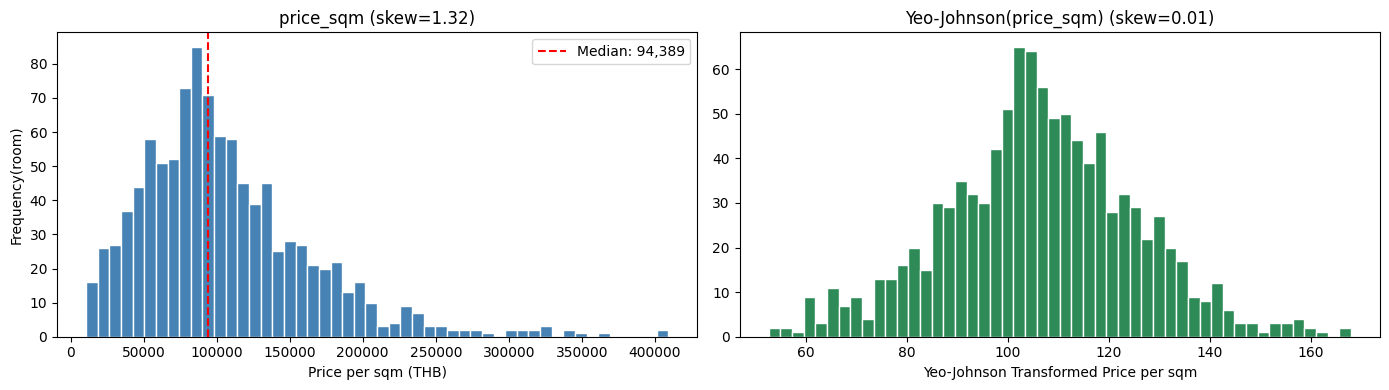

price_sqm range: 10,577 – 409,091 THB/sqm
→ Confirmed: ใช้ Yeo-Johnson target


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer

# ============================================================
# 3.1 Target Distribution
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
skew_val = df["price_sqm"].skew()

axes[0].hist(df['price_sqm'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title(f'price_sqm (skew={skew_val:.2f})')
axes[0].set_xlabel('Price per sqm (THB)')
axes[0].set_ylabel('Frequency(room)')
axes[0].axvline(df['price_sqm'].median(), color='red', linestyle='--', label=f'Median: {df["price_sqm"].median():,.0f}')
axes[0].legend()


# Apply Yeo-Johnson transformation
pt = PowerTransformer(method='yeo-johnson', standardize=False)
yeo_johnson_price = pt.fit_transform(df[['price_sqm']])

# Flatten the array for plotting
yeo_johnson_price = yeo_johnson_price.flatten()

axes[1].hist(yeo_johnson_price, bins=50, color='seagreen', edgecolor='white')
axes[1].set_title(f'Yeo-Johnson(price_sqm) (skew={pd.Series(yeo_johnson_price).skew():.2f})')
axes[1].set_xlabel('Yeo-Johnson Transformed Price per sqm')

plt.tight_layout()
plt.show()

print(f"price_sqm range: {df['price_sqm'].min():,} – {df['price_sqm'].max():,} THB/sqm")
print(f"→ Confirmed: ใช้ Yeo-Johnson target")

In [8]:
# เพิ่มคอลัมน์ price_sqm_transformed ลงใน DataFrame หลักเพื่อใช้เทรน
# เราจะใช้ PowerTransformer ตัวเดิม (pt) ที่ fit ไว้แล้ว
df['price_sqm_transformed'] = pt.transform(df[['price_sqm']])

print("สุ่มแสดงผลลัพธ์ของ price_sqm และค่าที่แปลงแล้ว (transformed):")
# สุ่มตัวอย่าง 10 แถวเพื่อเปรียบเทียบค่า
display(df[['price_sqm', 'price_sqm_transformed']].sample(10))

สุ่มแสดงผลลัพธ์ของ price_sqm และค่าที่แปลงแล้ว (transformed):


,price_sqm,price_sqm_transformed
291,118713,113.938636
996,78309,99.906818
14,93287,105.592347
912,232384,140.730709
717,207112,135.738012
661,43551,82.926052
307,89479,104.210665
330,80000,100.584605
900,155263,123.988461
514,41895,81.908031


In [9]:
# Display the number of units per district in a table
district_counts = df['district'].value_counts().reset_index()
district_counts.columns = ['District', 'Count']
display(district_counts)

# Recalculate district_price_stats as its definition was removed
district_price_stats = df.groupby('district')['price_sqm'].mean().nlargest(20)

print("\nTop 20 districts by average price_sqm (from previous output):")
display(district_price_stats)

,District,Count
0,Watthana,140
1,Chatuchak,84
2,Huai Khwang,73
3,Khlong Toei,70
4,Phaya Thai,67
5,Pathum Wan,46
6,Sathon,42
7,Phra Khanong,41
8,Ratchathewi,41
9,Bang Kapi,37



Top 20 districts by average price_sqm (from previous output):


,price_sqm
district,
Pom Prap Sattru Phai,198233.000000
Pathum Wan,183716.739130
Bang Rak,168357.848485
Ratchathewi,152936.512195
Watthana,143698.514286
Khlong Toei,139273.028571
Sathon,125284.047619
Khlong San,118245.793103
Samphanthawong,110201.333333


# **Boxplot ของราคาคอนโดต่อตารางเมตร (price_sqm) ใน 20 เขตยอดนิยม (เรียงตามราคามัธยฐาน) จะช่วยให้เราเข้าใจตลาดคอนโดในกรุงเทพฯ ได้ดังนี้:**

-การเปรียบเทียบราคามัธยฐาน:เส้นตรงกลางในแต่ละกล่องแสดงถึงราคามัธยฐานต่อตารางเมตรสำหรับเขตนั้นๆทำให้เราสามารถเปรียบเทียบราคาโดยทั่วไปในเขตที่มีมูลค่าสูงได้อย่างรวดเร็ว เขตที่อยู่ด้านบนของกราฟ (เช่น ป้อมปราบศัตรูพ่าย, ปทุมวัน) มีราคามัธยฐานสูงกว่า ซึ่งบ่งชี้ว่าโดยรวมแล้วเป็นเขตที่มีราคาแพงกว่า

-ความผันผวนของราคา (IQR): ความยาวของแต่ละกล่อง (ช่วงควอไทล์ หรือ IQR) แสดงถึงการกระจายของราคาสำหรับคอนโด 50% กลางในเขตนั้น ๆ กล่องที่ยาวกว่าบ่งบอกถึงความผันผวนของราคาที่มากกว่า หมายความว่ามีคอนโดหลากหลายประเภท (ตั้งแต่ราคาถูกไปจนถึงหรูหรามาก) ในพื้นที่นั้น ๆ กล่องที่สั้นกว่าแสดงว่าราคาค่อนข้างคงที่

-ค่าผิดปกติ (Outliers): จุดที่อยู่นอก 'หนวด' ของ boxplot แสดงถึงค่าผิดปกติ (outliers) ซึ่งเป็นคอนโดที่มีราคาที่สูงหรือต่ำผิดปกติสำหรับเขตนั้น ๆ การระบุจุดเหล่านี้สามารถชี้ไปถึงอสังหาริมทรัพย์ที่หรูหราเป็นพิเศษ การขายในราคาถูก หรือข้อผิดพลาดในการป้อนข้อมูล

-ความเบ้และรูปร่างของการกระจาย: แม้ว่าจะไม่ละเอียดเท่าฮิสโตแกรม แต่ตำแหน่งของเส้นมัธยฐานภายในกล่องและความยาวของหนวดสามารถให้แนวคิดทั่วไปเกี่ยวกับความเบ้ของการกระจายราคาภายในแต่ละเขตได้ ตัวอย่างเช่น หากมัธยฐานอยู่ใกล้ด้านล่างของกล่องและหนวดด้านบนยาวกว่า แสดงว่ามีการกระจายแบบเบ้ขวาที่มีบางยูนิตราคาสูงมาก

-การแบ่งส่วนตลาด: โดยการสังเกตช่วงราคาที่แตกต่างกันและการกระจายตัวในเขตเหล่านี้ คุณสามารถอนุมานการแบ่งส่วนตลาดที่แตกต่างกันได้ บางเขตอาจรองรับตลาดหรูหราที่มีความสม่ำเสมอ ในขณะที่บางเขตอาจมีทั้งตัวเลือกหรูหราและระดับกลางผสมกัน

-โดยสรุป boxplot นี้ช่วยให้เข้าใจภาพรวมของราคาตลาดคอนโดในกรุงเทพฯ โดยเน้นว่าเขตใดมีราคาแพงที่สุด เขตใดมีความผันผวนของราคาสูงสุด และมีจุดราคาที่ผิดปกติอยู่ที่ใดบ้าง

# **การอ่าน Boxplot**

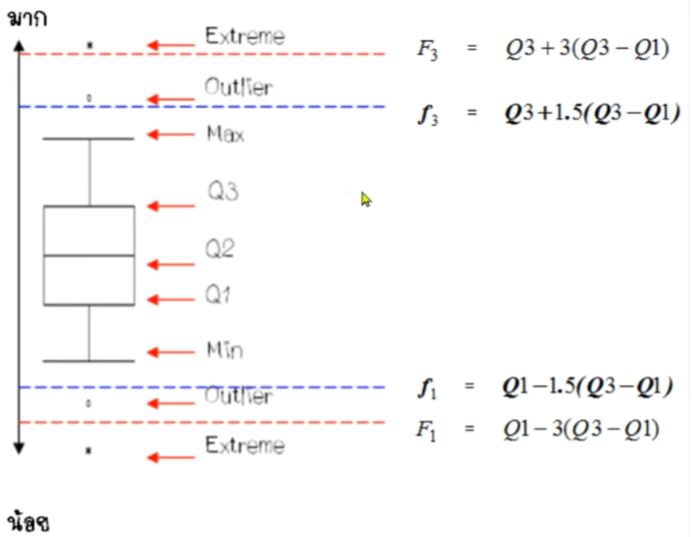

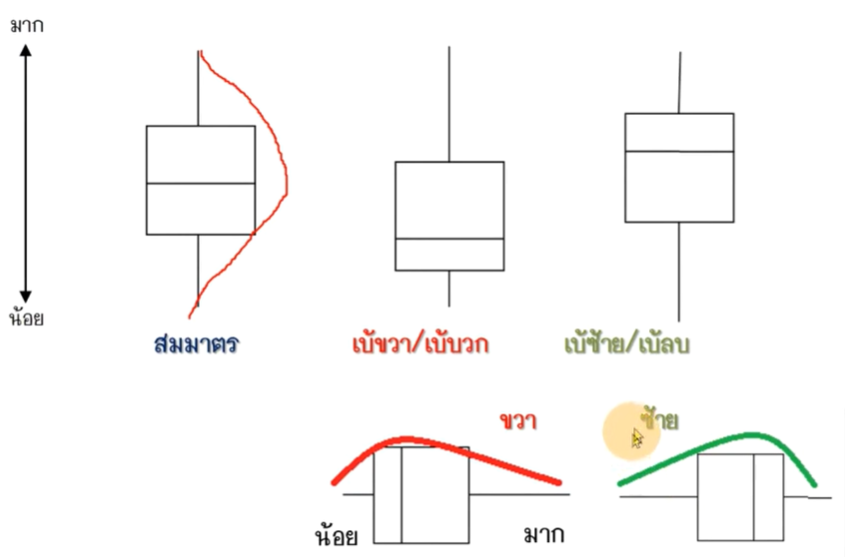



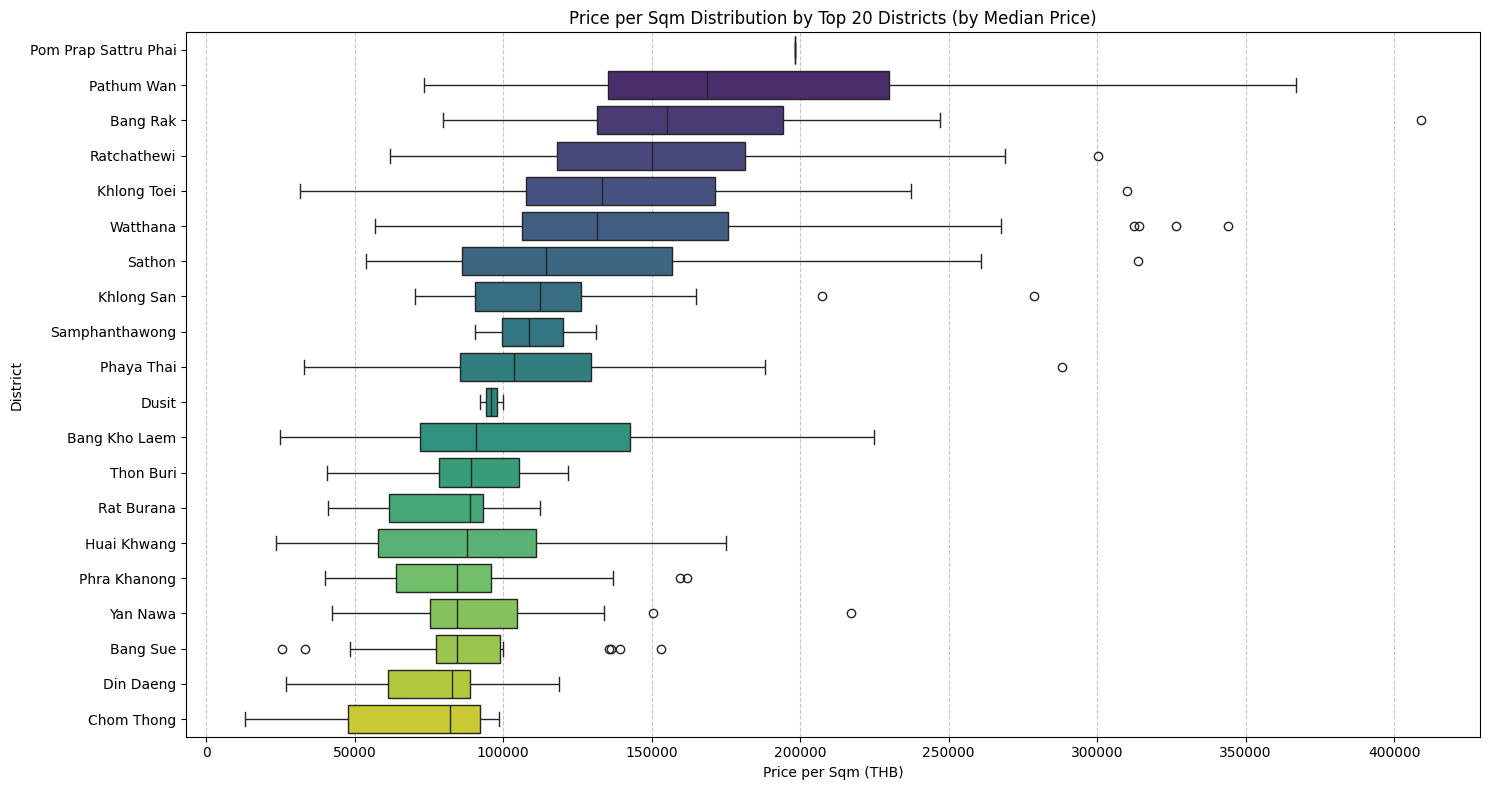

In [10]:
# Calculate median price_sqm for each district
median_prices = df.groupby('district')['price_sqm'].median().sort_values(ascending=False)

# Get the top 20 districts by median price
top_20_districts = median_prices.head(20).index.tolist()

# Filter the DataFrame to include only the top 20 districts
df_top_20 = df[df['district'].isin(top_20_districts)]

# Order the districts for plotting
df_top_20['district'] = pd.Categorical(df_top_20['district'], categories=top_20_districts, ordered=True)

# Create the boxplot
plt.figure(figsize=(15, 8))
sns.boxplot(x='price_sqm', y='district', data=df_top_20, palette='viridis')
plt.title('Price per Sqm Distribution by Top 20 Districts (by Median Price)')
plt.xlabel('Price per Sqm (THB)')
plt.ylabel('District')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# **การทำ Geographic Visualization โดยใช้ scatter plot นี้ ช่วยให้เราเห็นอะไรจากข้อมูล**

1.การรวมกลุ่มเชิงพื้นที่ (Spatial Clustering): เราจะเห็นได้ทันทีว่าคอนโดส่วนใหญ่กระจุกตัวอยู่ในบริเวณไหน และย่านไหนที่มีราคา (สี) ใกล้เคียงกัน เช่น กลุ่มสีแดงที่กระจุกตัวอยู่รอบๆ สยาม อโศก และสีลม แสดงถึงย่าน Central Business District (CBD) ที่มีมูลค่าสูง

2.ความสัมพันธ์ระหว่างตำแหน่งและราคา: ช่วยให้เห็นว่ายิ่งขยับออกจากจุด Landmarks สำคัญ ราคาจะค่อยๆ ลดลง (สีเปลี่ยนจากโทนร้อนเป็นโทนเย็น) หรือไม่ ซึ่งเป็นปัจจัยสำคัญที่โมเดลจะใช้ในการทำนาย

3.การตรวจสอบความผิดปกติ (Outlier Detection): หากมีจุดสีแดง (ราคาสูง) ไปโผล่ในย่านที่จุดรอบๆ เป็นสีน้ำเงิน (ราคาต่ำ) ทั้งหมด เราจะสังเกตเห็นได้ง่ายขึ้น เพื่อตรวจสอบว่าเป็นข้อมูลที่ผิดพลาดหรือเป็นโครงการระดับหรูที่ตั้งอยู่ในทำเลนั้นจริงๆ

4.ผลลัพธ์จากการแปลงข้อมูล (After Transformation): การใช้ค่าที่ผ่าน Yeo-Johnson ช่วยให้สีของจุดกระจายตัวได้ดีขึ้น ไม่ถูกดึงด้วยค่าที่โด่งเกินไป ทำให้เราเห็นความแตกต่างของราคาในโซนต่างๆ ได้ชัดเจนและสมจริงมากขึ้นครับ

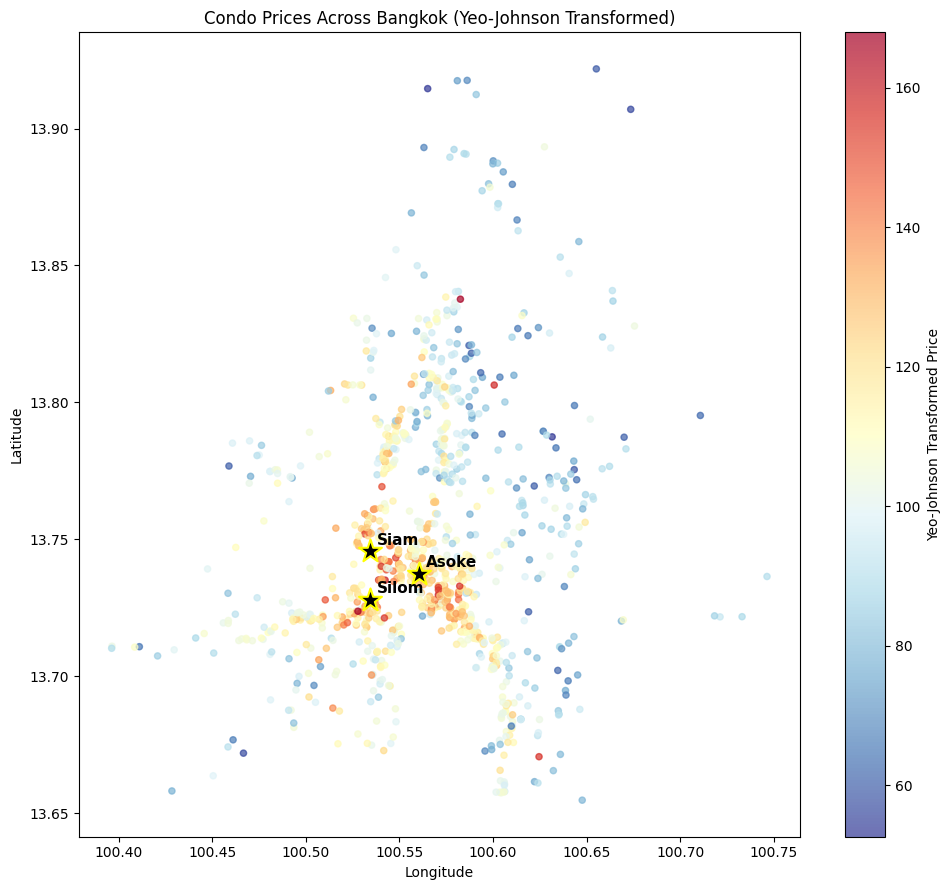

In [11]:
# ============================================================
# 3.3 Geographic Visualization พล็อตคอนโดลงบนแผนที่กรุงเทพ โดยใช้ค่าที่ผ่าน Yeo-Johnson Transformation
# ============================================================
fig, ax = plt.subplots(figsize=(10, 9))

# เปลี่ยนจาก np.log1p(df['price_sqm']) เป็น df['price_sqm_transformed']
scatter = ax.scatter(df['longitude'], df['latitude'],
                     c=df['price_sqm_transformed'],
                     cmap='RdYlBu_r', s=20, alpha=0.7)

plt.colorbar(scatter, label='Yeo-Johnson Transformed Price') # เปลี่ยน Label ให้ตรงกับข้อมูลใหม่

# Mark landmarks
landmarks = {'Siam': (100.5343, 13.7456),
             'Asoke': (100.5602, 13.7375),
             'Silom': (100.5340, 13.7280)}

# วน loop ทุก landmark พล็อตเป็นดาว
for name, (lon, lat) in landmarks.items():
    ax.scatter(lon, lat, marker='*', s=300, c='black', edgecolors='yellow', linewidths=1.5)
    ax.annotate(name, (lon, lat), fontsize=11, fontweight='bold', xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Condo Prices Across Bangkok (Yeo-Johnson Transformed)')
plt.tight_layout()
plt.show()

# **3.5 Low-variance Features **

หาข้อมูลไม่มีอำนาจในการแยกแยะ (Lack of Information): หากฟีเจอร์หนึ่งมีค่าเหมือนกันเกือบทั้งหมด (เช่น คอนโด 99.7% มี CCTV เหมือนกัน) ฟีเจอร์นั้นจะแทบไม่ช่วยให้โมเดลแยกแยะได้เลยว่าทำไมคอนโดห้องหนึ่งถึงราคาแพงกว่าอีกห้องหนึ่ง เพื่อ drop feature นั้นทิ้งก่อนเทรน

1. unique_values = 2: หมายความว่าในคอลัมน์นี้มีคำตอบเพียง 2 แบบเท่านั้น (คือ 0 กับ 1 หรือ มี กับ ไม่มี)

2. most_freq_value_pct = 99.71: หมายความว่าข้อมูลส่วนใหญ่ถึง 99.71% เป็นค่าเดียวกันทั้งหมด (ในที่นี้คือเกือบทุกคอนโดมี CCTV)

3. min_class_pct = 0.29: หมายความว่ามีข้อมูลเพียง 0.29% เท่านั้นที่แตกต่างออกไป (หรือมีคอนโดเพียงประมาณ 95 ห้องจาก 32,745 ห้องที่ไม่มี CCTV)

*มันบ่งบอก Variance อย่างไร? *

ในเชิงสถิติ Variance คือการวัดการกระจายตัว ถ้าข้อมูลเกือบทั้งหมดเป็นค่าเดียวกัน (99.71%) แปลว่าข้อมูล 'แทบไม่มีการกระจายตัวเลย' หรือมีความแปรปรวนต่ำมาก (Low Variance) นั่นเองครับ

เปรียบเทียบง่ายๆ:

-ถ้าคอนโดทุกแห่งมี CCTV เหมือนกันหมด (100%) -> Variance = 0 (ไม่มีความต่างเลย)

-กรณีนี้มีคนไม่มี CCTV แค่ 0.29% -> Variance จึงเข้าใกล้ 0 มากๆ ทำให้ฟีเจอร์นี้ไม่มีพลังในการทำนายว่าห้องไหนจะถูกหรือแพงกว่ากันครับ

In [12]:
# ============================================================
# 3.5 Low-variance Features Check (All Features)
# ============================================================

# คำนวณหาความหลากหลายของข้อมูลในทุกคอลัมน์
variance_data = []
for col in df.columns:
    if col in ['price_sqm', 'price_sqm_transformed']: continue

    # หาค่าที่ปรากฏบ่อยที่สุดและสัดส่วน
    top_value_pct = df[col].value_counts(normalize=True).iloc[0] * 100
    minority_pct = 100 - top_value_pct

    variance_data.append({
        'feature': col,
        'most_freq_value_pct': top_value_pct,
        'min_class_pct': minority_pct,
        'unique_values': df[col].nunique()
    })

variance_check = pd.DataFrame(variance_data).set_index('feature').round(2)
variance_check = variance_check.sort_values('min_class_pct')

print("Variance check for all features:")
display(variance_check)

# กรองหาฟีเจอร์ที่มีกลุ่มน้อยต่ำกว่า 5% (ข้อมูลซ้ำกันมากกว่า 95%)
low_var_to_drop = variance_check[variance_check['min_class_pct'] < 5].index.tolist()
print(f"\n→ Low-variance features (<5% minority class) recommended to drop: {low_var_to_drop}")

# --- เพิ่มโค้ดสำหรับ Drop Column ---
# ลบคอลัมน์ที่มี Low Variance ออกจาก DataFrame หลัก
df_dropped = df.drop(columns=low_var_to_drop)

print(f"\nทำการ Drop {len(low_var_to_drop)} คอลัมน์เรียบร้อยแล้ว")
print(f"Shape เดิม: {df.shape} -> Shape ใหม่: {df_dropped.shape}")

# อัปเดตตัวแปร df (หรือจะใช้ df_dropped ต่อไปก็ได้ครับ)
df = df_dropped
df.head()

Variance check for all features:


,most_freq_value_pct,min_class_pct,unique_values
feature,,,
CCTV,99.71,0.29,2
Parking,99.12,0.88,2
Security,98.82,1.18,2
Elevator,97.15,2.85,2
Gym,87.73,12.27,2
Pool,87.14,12.86,2
Restaurant,84.89,15.11,2
Playground,72.82,27.18,2
Shop,69.09,30.91,2



→ Low-variance features (<5% minority class) recommended to drop: ['CCTV', 'Parking', 'Security', 'Elevator']

ทำการ Drop 4 คอลัมน์เรียบร้อยแล้ว
Shape เดิม: (1019, 56) -> Shape ใหม่: (1019, 52)


,name,district,latitude,longitude,year_built,proj_area,nbr_buildings,nbr_floors,units,hospital,...,tran_name2,tran_name3,tran_name4,tran_name5,dist_tran_1,dist_tran_2,dist_tran_3,dist_tran_4,dist_tran_5,price_sqm_transformed
0,101 Mansion,Bang Kapi,13.787435,100.631564,1991,23371,5,5,834.0,2.10,...,Yothin Phatthana Toll Plaza,Pracha Uthit Toll Plaza,Sutthisan,Huai Khwang,4.3,4.8,5.0,8.1,8.3,52.593325
1,624 Condolette Ladprao,Bang Kapi,13.766348,100.649395,2011,6476,2,8,471.0,1.80,...,Srinagarindra Toll Plaza,Pracha Uthit Toll Plaza,Huai Khwang,Thailand Cultural Centre,5.8,6.2,6.5,9.8,9.9,86.130187
2,Adamas Ramkhamhaeng,Bang Kapi,13.752448,100.615507,1995,4699,1,16,140.0,2.30,...,Ramkhamhaeng Toll Plaza,Phatthanakan 2 Toll Plaza,Phra Khanong,Ekkamai,2.1,2.5,2.9,6.1,6.3,74.496714
3,Aspire Ladprao 113,Bang Kapi,13.770286,100.638799,2016,3816,1,8,270.0,0.68,...,Pracha Uthit Toll Plaza,Srinagarindra Toll Plaza,Sutthisan,Huai Khwang,4.7,5.4,6.1,8.5,8.7,103.427074
4,B.R. Condo,Bang Kapi,13.768706,100.638876,1991,7391,2,10,560.0,0.69,...,Pracha Uthit Toll Plaza,Srinagarindra Toll Plaza,Sutthisan,Huai Khwang,4.7,5.4,6.1,8.5,8.6,82.342931


# หา Correlation ของกลุ่มข้อมูล ระยะทางถึงสถานีรถไฟ โรงเรียน ร้านค้า ร้านอาหาร เพื่อดูว่ามีกลุ่มไหนที่มีความเกี่ยวข้องกันมากเกินไป อาจทำให้โมเดลสับสนได้

จากผลลัพธ์ที่ได้จากโค้ดนี้ เราสามารถอธิบายความสัมพันธ์ (Correlation) ของกลุ่มข้อมูลระยะทางได้ดังนี้ครับ:

กลุ่ม Shop (0.081) และ Food (0.096): มีค่า Correlation เฉลี่ยต่ำมาก (เกือบเป็น 0) บ่งบอกว่าระยะห่างของร้านค้าหรือร้านอาหารแต่ละแห่ง 'กระจายตัวอย่างอิสระ' ไม่จำเป็นว่าถ้าไกลจากร้านที่ 1 แล้วจะต้องไกลจากร้านที่ 2, 3 เสมอไปครับ

กลุ่ม School (0.794) และ Tran (0.875): มีค่า Correlation สูงมาก บ่งบอกถึงความสัมพันธ์แบบไปในทิศทางเดียวกันอย่างชัดเจน หมายความว่าหากคอนโดนั้น 'อยู่ไกลจากโรงเรียนหรือสถานีขนส่งแห่งหนึ่ง ก็มักจะอยู่ไกลจากแห่งอื่นๆ ในกลุ่มนั้นด้วย' ซึ่งสะท้อนว่าสิ่งอำนวยความสะดวกเหล่านี้มักจะกระจุกตัวอยู่ในโซนเดียวกัน

ในเชิงการสร้าง Model:

กลุ่ม School และ Tran มีความสัมพันธ์กันเองสูง (Multicollinearity) ซึ่งอาจพิจารณาเลือกใช้เพียงบางคอลัมน์

In [13]:
# ============================================================
# 3.6 Pairwise correlation of distance ranks (dist_*_1..5)
# ============================================================
for group in ['shop', 'school', 'food', 'tran']:
    cols = [f'dist_{group}_{i}' for i in range(1, 6)]
    #print(cols)
    corr = df[cols].corr()
    #print(corr)

    #print(f"\n{group} distance correlation (off-diagonal mean = {corr.values[np.triu_indices(5, k=1)].mean():.3f}):")

    n = len(corr)                                   # ขนาด matrix (5) len นับแถว
    #print(n)
    diagonal_mask = np.eye(n, dtype=bool)           # True ที่เส้นทแยง, False ที่อื่น n=5 จากบรรทัดบน
    #print(diagonal_mask)
    off_diag_values = corr.values[~diagonal_mask]   # เอาเฉพาะค่าที่ไม่ใช่เส้นทแยงเพราะเป็น1 เนื่องจากเป็นความสัมพันธ์กับตัวเอง วนลูป4รอบจากคำสั่ง for โดยดึงค่าของ 'shop', 'school', 'food', 'tran'
    avg_correlation = off_diag_values.mean()        # เฉลี่ยค่าที่ได้จาก off_diag_values

    print(f"\n{group} distance correlation (avg = {avg_correlation:.3f}):")
    print(corr.round(2))


shop distance correlation (avg = 0.081):
             dist_shop_1  dist_shop_2  dist_shop_3  dist_shop_4  dist_shop_5
dist_shop_1         1.00         -0.0         -0.0         0.01        -0.01
dist_shop_2        -0.00          1.0          0.0        -0.00        -0.00
dist_shop_3        -0.00          0.0          1.0        -0.00        -0.00
dist_shop_4         0.01         -0.0         -0.0         1.00         0.81
dist_shop_5        -0.01         -0.0         -0.0         0.81         1.00

school distance correlation (avg = 0.794):
               dist_school_1  dist_school_2  dist_school_3  dist_school_4  \
dist_school_1           1.00           0.84           0.77           0.67   
dist_school_2           0.84           1.00           0.92           0.79   
dist_school_3           0.77           0.92           1.00           0.85   
dist_school_4           0.67           0.79           0.85           1.00   
dist_school_5           0.64           0.76           0.81         

In [14]:
# ============================================================
# 3.7 Aggregate distance groups by keeping only the Minimum value
# ============================================================

# สำหรับกลุ่ม school และ tran เราจะหาค่าที่น้อยที่สุด (ระยะทางที่ใกล้ที่สุด)
# มาเป็นตัวแทนเพียงคอลัมน์เดียว และลบคอลัมน์ลำดับ 1-5 ทิ้งทั้งหมด

for group in ['school', 'tran']:
    cols = [f'dist_{group}_{i}' for i in range(1, 6)]

    # สร้างคอลัมน์ใหม่ที่เก็บค่า Min (ระยะทางที่สั้นที่สุด)
    df[f'dist_{group}_min'] = df[cols].min(axis=1)

    # Drop คอลัมน์เดิมออกทั้งหมด
    df = df.drop(columns=cols)

print(f"Created 'dist_school_min' and 'dist_tran_min' successfully.")
print(f"New shape: {df.shape}")

# ตรวจสอบตัวอย่างข้อมูลที่ได้
display(df[['dist_school_min', 'dist_tran_min']].head())



Created 'dist_school_min' and 'dist_tran_min' successfully.
New shape: (1019, 44)


,dist_school_min,dist_tran_min
0,1.20,4.3
1,0.56,5.8
2,0.64,2.1
3,0.71,4.7
4,0.63,4.7


In [15]:
df.head()

,name,district,latitude,longitude,year_built,proj_area,nbr_buildings,nbr_floors,units,hospital,...,tran_type4,tran_type5,tran_name1,tran_name2,tran_name3,tran_name4,tran_name5,price_sqm_transformed,dist_school_min,dist_tran_min
0,101 Mansion,Bang Kapi,13.787435,100.631564,1991,23371,5,5,834.0,2.10,...,mrt,mrt,Lat Phrao Toll Plaza,Yothin Phatthana Toll Plaza,Pracha Uthit Toll Plaza,Sutthisan,Huai Khwang,52.593325,1.20,4.3
1,624 Condolette Ladprao,Bang Kapi,13.766348,100.649395,2011,6476,2,8,471.0,1.80,...,mrt,mrt,Lat Phrao Toll Plaza,Srinagarindra Toll Plaza,Pracha Uthit Toll Plaza,Huai Khwang,Thailand Cultural Centre,86.130187,0.56,5.8
2,Adamas Ramkhamhaeng,Bang Kapi,13.752448,100.615507,1995,4699,1,16,140.0,2.30,...,bts,bts,Srinagarindra Toll Plaza,Ramkhamhaeng Toll Plaza,Phatthanakan 2 Toll Plaza,Phra Khanong,Ekkamai,74.496714,0.64,2.1
3,Aspire Ladprao 113,Bang Kapi,13.770286,100.638799,2016,3816,1,8,270.0,0.68,...,mrt,mrt,Lat Phrao Toll Plaza,Pracha Uthit Toll Plaza,Srinagarindra Toll Plaza,Sutthisan,Huai Khwang,103.427074,0.71,4.7
4,B.R. Condo,Bang Kapi,13.768706,100.638876,1991,7391,2,10,560.0,0.69,...,mrt,mrt,Lat Phrao Toll Plaza,Pracha Uthit Toll Plaza,Srinagarindra Toll Plaza,Sutthisan,Huai Khwang,82.342931,0.63,4.7


In [16]:
# แสดงรายชื่อ feature ทั้งหมดใน df ล่าสุดเป็นตาราง
current_features = df.columns.tolist()
features_table = pd.DataFrame(current_features, columns=['Current Feature Name'])

print(f"Total features: {len(current_features)}")
display(features_table)

Total features: 44


,Current Feature Name
0,name
1,district
2,latitude
3,longitude
4,year_built
5,proj_area
6,nbr_buildings
7,nbr_floors
8,units
9,hospital


In [17]:
# ระบุ index ของคอลัมน์ที่ต้องการลบ
indices_to_drop = [0, 11] + list(range(31, 41))

# ดึงชื่อคอลัมน์จาก index
cols_to_drop = df.columns[indices_to_drop].tolist()

print(f"Columns to be dropped: {cols_to_drop}")

# ลบคอลัมน์
df = df.drop(columns=cols_to_drop)

print(f"Remaining columns: {len(df.columns)}")
display(df.head())

Columns to be dropped: ['name', 'id', 'tran_type1', 'tran_type2', 'tran_type3', 'tran_type4', 'tran_type5', 'tran_name1', 'tran_name2', 'tran_name3', 'tran_name4', 'tran_name5']
Remaining columns: 32


,district,latitude,longitude,year_built,proj_area,nbr_buildings,nbr_floors,units,hospital,price_sqm,...,Sauna,Gym,Garden,Playground,Shop,Restaurant,Wifi,price_sqm_transformed,dist_school_min,dist_tran_min
0,Bang Kapi,13.787435,100.631564,1991,23371,5,5,834.0,2.10,10577,...,0,0,1,0,1,0,0,52.593325,1.20,4.3
1,Bang Kapi,13.766348,100.649395,2011,6476,2,8,471.0,1.80,49059,...,0,1,1,0,1,1,1,86.130187,0.56,5.8
2,Bang Kapi,13.752448,100.615507,1995,4699,1,16,140.0,2.30,31129,...,0,0,0,0,1,0,1,74.496714,0.64,2.1
3,Bang Kapi,13.770286,100.638799,2016,3816,1,8,270.0,0.68,87368,...,1,1,0,0,0,0,0,103.427074,0.71,4.7
4,Bang Kapi,13.768706,100.638876,1991,7391,2,10,560.0,0.69,42597,...,0,0,0,0,1,0,0,82.342931,0.63,4.7


In [18]:
import numpy as np

def haversine_distance(lat1, lon1, lat2, lon2):
    # รัศมีของโลก (กิโลเมตร)
    R = 6371.0

    # แปลงองศาเป็นเรเดียน
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # สูตร Haversine
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

# พิกัด CBD Landmarks
LANDMARKS = {
    'siam':  (13.7456, 100.5343),
    'asoke': (13.7375, 100.5602),
    'silom': (13.7280, 100.5340),
}

# 1. คำนวณระยะทางสำหรับแต่ละ Landmark
for name, coords in LANDMARKS.items():
    df[f'dist_to_{name}'] = haversine_distance(df['latitude'], df['longitude'], coords[0], coords[1])

# 2. Drop คอลัมน์ latitude และ longitude ตามคำสั่ง
df = df.drop(columns=['latitude', 'longitude'])

print("เพิ่มคอลัมน์ระยะทางไป CBD และลบ latitude/longitude เรียบร้อยแล้ว:")
display(df[['dist_to_siam', 'dist_to_asoke', 'dist_to_silom']].head())
print(f"Shape ปัจจุบัน: {df.shape}")

df.head()

เพิ่มคอลัมน์ระยะทางไป CBD และลบ latitude/longitude เรียบร้อยแล้ว:


,dist_to_siam,dist_to_asoke,dist_to_silom
0,11.488468,9.499220,12.438346
1,12.643173,10.153732,13.173007
2,8.804078,6.200687,9.213977
3,11.615382,9.238899,12.256960
4,11.583269,9.178719,12.198401


Shape ปัจจุบัน: (1019, 33)


,district,year_built,proj_area,nbr_buildings,nbr_floors,units,hospital,price_sqm,bld_age,dist_shop_1,...,Playground,Shop,Restaurant,Wifi,price_sqm_transformed,dist_school_min,dist_tran_min,dist_to_siam,dist_to_asoke,dist_to_silom
0,Bang Kapi,1991,23371,5,5,834.0,2.10,10577,28,1.500,...,0,1,0,0,52.593325,1.20,4.3,11.488468,9.499220,12.438346
1,Bang Kapi,2011,6476,2,8,471.0,1.80,49059,8,0.400,...,0,1,1,1,86.130187,0.56,5.8,12.643173,10.153732,13.173007
2,Bang Kapi,1995,4699,1,16,140.0,2.30,31129,24,0.003,...,0,1,0,1,74.496714,0.64,2.1,8.804078,6.200687,9.213977
3,Bang Kapi,2016,3816,1,8,270.0,0.68,87368,3,0.002,...,0,0,0,0,103.427074,0.71,4.7,11.615382,9.238899,12.256960
4,Bang Kapi,1991,7391,2,10,560.0,0.69,42597,28,0.002,...,0,1,0,0,82.342931,0.63,4.7,11.583269,9.178719,12.198401


# corelation ของแต่ละ feature กับ price_sqm

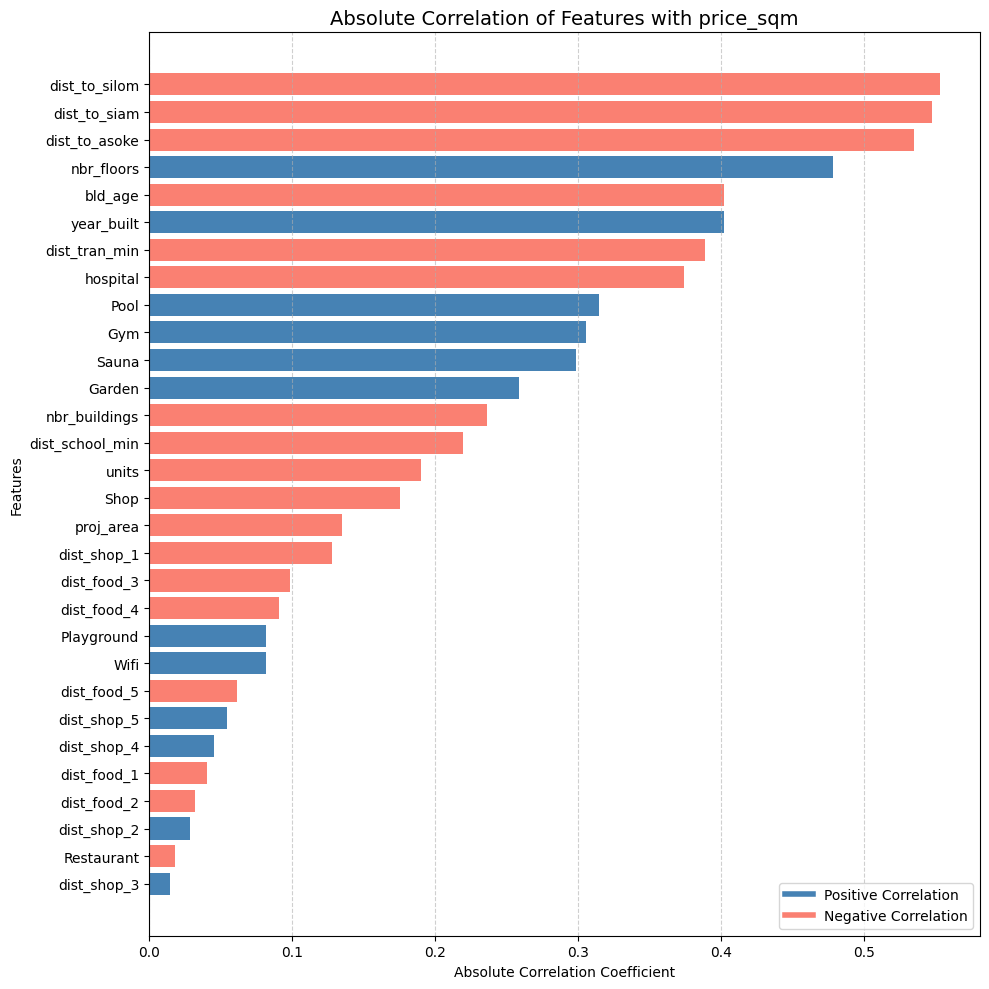

In [19]:
# ============================================================
# 3.8 Absolute Correlation with price_sqm
# ============================================================

# เลือกเฉพาะคอลัมน์ที่เป็นตัวเลข
numeric_cols = df.select_dtypes(include=[np.number]).columns

# คำนวณ Correlation ปกติก่อนเพื่อเอาทิศทาง (+/-)
corr_series = df[numeric_cols].corr()['price_sqm'].drop(['price_sqm', 'price_sqm_transformed'], errors='ignore')

# สร้าง DataFrame เพื่อจัดการค่า Absolute และสี
corr_df = pd.DataFrame({
    'feature': corr_series.index,
    'corr_val': corr_series.values,
    'abs_corr': corr_series.abs().values
})

# เรียงลำดับตามค่า Absolute Correlation
corr_df = corr_df.sort_values(by='abs_corr', ascending=True)

# กำหนดสี: ถ้าค่า corr จริงๆ เป็นลบ ให้เป็นสีส้ม (salmon), ถ้าเป็นบวกให้เป็นสีน้ำเงิน (steelblue)
colors = ['steelblue' if x > 0 else 'salmon' for x in corr_df['corr_val']]

# สร้างกราฟแท่งแนวนอน
plt.figure(figsize=(10, 10))
plt.barh(corr_df['feature'], corr_df['abs_corr'], color=colors)

plt.title('Absolute Correlation of Features with price_sqm', fontsize=14)
plt.xlabel('Absolute Correlation Coefficient')
plt.ylabel('Features')

# เพิ่ม Legend อธิบายสี
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color='steelblue', lw=4, label='Positive Correlation'),
                   Line2D([0], [0], color='salmon', lw=4, label='Negative Correlation')]
plt.legend(handles=legend_elements, loc='lower right')

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Low Correlation with Target: ฟีเจอร์ที่มีค่า Absolute Correlation ต่ำมากๆ (เช่น < 0.05) มักเป็น Noise ที่ไม่ช่วยในการทำนาย

In [20]:
# 1. กำหนดเกณฑ์การตัดสินใจ (Threshold)
threshold = 0.05

# 2. ค้นหาฟีเจอร์ที่มี Absolute Correlation ต่ำกว่าเกณฑ์
low_corr_features = corr_df[corr_df['abs_corr'] < threshold]['feature'].tolist()

# 3. แสดงรายงานการ Drop
print(f"--- รายงานการจัดการ Feature ---")
print(f"เกณฑ์ที่ใช้: Absolute Correlation < {threshold}")
print(f"จำนวนฟีเจอร์ที่ถูกนำออก: {len(low_corr_features)} ฟีเจอร์")
print(f"รายชื่อฟีเจอร์ที่ถูก Drop: {low_corr_features}")

# 4. ทำการลบคอลัมน์ออกจาก DataFrame
df = df.drop(columns=low_corr_features)

print(f"\nจำนวนฟีเจอร์ที่เหลืออยู่: {len(df.columns)}")
display(df.head())

--- รายงานการจัดการ Feature ---
เกณฑ์ที่ใช้: Absolute Correlation < 0.05
จำนวนฟีเจอร์ที่ถูกนำออก: 6 ฟีเจอร์
รายชื่อฟีเจอร์ที่ถูก Drop: ['dist_shop_3', 'Restaurant', 'dist_shop_2', 'dist_food_2', 'dist_food_1', 'dist_shop_4']

จำนวนฟีเจอร์ที่เหลืออยู่: 27


,district,year_built,proj_area,nbr_buildings,nbr_floors,units,hospital,price_sqm,bld_age,dist_shop_1,...,Garden,Playground,Shop,Wifi,price_sqm_transformed,dist_school_min,dist_tran_min,dist_to_siam,dist_to_asoke,dist_to_silom
0,Bang Kapi,1991,23371,5,5,834.0,2.10,10577,28,1.500,...,1,0,1,0,52.593325,1.20,4.3,11.488468,9.499220,12.438346
1,Bang Kapi,2011,6476,2,8,471.0,1.80,49059,8,0.400,...,1,0,1,1,86.130187,0.56,5.8,12.643173,10.153732,13.173007
2,Bang Kapi,1995,4699,1,16,140.0,2.30,31129,24,0.003,...,0,0,1,1,74.496714,0.64,2.1,8.804078,6.200687,9.213977
3,Bang Kapi,2016,3816,1,8,270.0,0.68,87368,3,0.002,...,0,0,0,0,103.427074,0.71,4.7,11.615382,9.238899,12.256960
4,Bang Kapi,1991,7391,2,10,560.0,0.69,42597,28,0.002,...,0,0,1,0,82.342931,0.63,4.7,11.583269,9.178719,12.198401


### **3.11 Alternative: Weighted Amenity Score**
คำนวณคะแนนสิ่งอำนวยความสะดวกแบบถ่วงน้ำหนัก โดยใช้ค่า Absolute Correlation กับ `price_sqm` เป็นน้ำหนัก (Weights) เพื่อให้ฟีเจอร์ที่ส่งผลต่อราคามากกว่ามีคะแนนสูงกว่า

In [21]:
# 1. กำหนดรายชื่อคอลัมน์สิ่งอำนวยความสะดวก
amenity_cols = ['Pool', 'Sauna', 'Gym', 'Garden', 'Playground', 'Shop', 'Wifi']

# 2. คำนวณ Correlation ของแต่ละ Amenity กับ price_sqm เพื่อใช้เป็นน้ำหนัก (Weights)
# เราใช้ค่า Absolute เพื่อให้น้ำหนักเป็นบวกเสมอ
amenity_corrs = df[amenity_cols + ['price_sqm']].corr()['price_sqm'].drop('price_sqm')
amenity_weights = amenity_corrs.abs()

print("Weights (Absolute Correlation with price_sqm):")
print(amenity_weights.sort_values(ascending=False))

# 3. สร้าง feature ใหม่: weighted_amenity_score
# คำนวณจาก ผลรวมของ (คอลัมน์สิ่งอำนวยความสะดวก * น้ำหนักของมัน)
df['weighted_amenity_score'] = (df[amenity_cols] * amenity_weights).sum(axis=1)

# 4. ลบคอลัมน์ความสะดวกสบายเดิมออก
df = df.drop(columns=amenity_cols)

print(f"\nสร้าง 'weighted_amenity_score' และลบคอลัมน์เดิม {len(amenity_cols)} คอลัมน์เรียบร้อยแล้ว")
display(df[['weighted_amenity_score']].head())
print(f"Shape ปัจจุบัน: {df.shape}")

Weights (Absolute Correlation with price_sqm):
Pool          0.314632
Gym           0.305446
Sauna         0.298647
Garden        0.258407
Shop          0.175695
Playground    0.081968
Wifi          0.081577
Name: price_sqm, dtype: float64

สร้าง 'weighted_amenity_score' และลบคอลัมน์เดิม 7 คอลัมน์เรียบร้อยแล้ว


,weighted_amenity_score
0,0.434102
1,0.821125
2,0.257272
3,0.918725
4,0.175695


Shape ปัจจุบัน: (1019, 21)


# จัดการกับ feature ที่เหลือยู่ ที่มีนิยามไม่ชัดเจนจากแหล่งข้อมูล

ได้แก่ dist_shop_1 , dist_shop_5 , dist_food_3 , dist_food_4 , dist_food_5

In [22]:
# ============================================================
# Aggregate Unclear Features (Shop & Food) using Min Value
# ============================================================

# 1. จัดการกลุ่ม Shop (ใช้ค่าที่น้อยที่สุดระหว่าง dist_shop_1 และ dist_shop_5)
shop_cols = ['dist_shop_1', 'dist_shop_5']
df['dist_shop_min'] = df[shop_cols].min(axis=1)

# 2. จัดการกลุ่ม Food (ใช้ค่าที่น้อยที่สุดระหว่าง dist_food_3, dist_food_4 และ dist_food_5)
food_cols = ['dist_food_3', 'dist_food_4', 'dist_food_5']
df['dist_food_min'] = df[food_cols].min(axis=1)

# 3. ลบคอลัมน์เดิมออก
df = df.drop(columns=shop_cols + food_cols)

print("ยุบรวมฟีเจอร์ dist_shop และ dist_food โดยใช้ค่า Min เรียบร้อยแล้ว")
print(f"จำนวนฟีเจอร์ปัจจุบัน: {len(df.columns)}")
display(df[['dist_shop_min', 'dist_food_min']].head())

ยุบรวมฟีเจอร์ dist_shop และ dist_food โดยใช้ค่า Min เรียบร้อยแล้ว
จำนวนฟีเจอร์ปัจจุบัน: 18


,dist_shop_min,dist_food_min
0,1.500,1.30
1,0.400,0.59
2,0.003,0.52
3,0.002,0.52
4,0.002,0.50


In [23]:
# แสดงรายชื่อ feature ที่เหลืออยู่ทั้งหมดในปัจจุบันเป็นตาราง
current_features = df.columns.tolist()
features_table = pd.DataFrame(current_features, columns=['Remaining Feature Name'])

print(f"Total remaining features: {len(current_features)}")
display(features_table)
display(df.head())

Total remaining features: 18


,Remaining Feature Name
0,district
1,year_built
2,proj_area
3,nbr_buildings
4,nbr_floors
5,units
6,hospital
7,price_sqm
8,bld_age
9,price_sqm_transformed


,district,year_built,proj_area,nbr_buildings,nbr_floors,units,hospital,price_sqm,bld_age,price_sqm_transformed,dist_school_min,dist_tran_min,dist_to_siam,dist_to_asoke,dist_to_silom,weighted_amenity_score,dist_shop_min,dist_food_min
0,Bang Kapi,1991,23371,5,5,834.0,2.10,10577,28,52.593325,1.20,4.3,11.488468,9.499220,12.438346,0.434102,1.500,1.30
1,Bang Kapi,2011,6476,2,8,471.0,1.80,49059,8,86.130187,0.56,5.8,12.643173,10.153732,13.173007,0.821125,0.400,0.59
2,Bang Kapi,1995,4699,1,16,140.0,2.30,31129,24,74.496714,0.64,2.1,8.804078,6.200687,9.213977,0.257272,0.003,0.52
3,Bang Kapi,2016,3816,1,8,270.0,0.68,87368,3,103.427074,0.71,4.7,11.615382,9.238899,12.256960,0.918725,0.002,0.52
4,Bang Kapi,1991,7391,2,10,560.0,0.69,42597,28,82.342931,0.63,4.7,11.583269,9.178719,12.198401,0.175695,0.002,0.50


In [24]:
# ลบคอลัมน์ year_built ออกเนื่องจากมีความซ้ำซ้อนกับ bld_age
df = df.drop(columns=['year_built'])

print("ลบคอลัมน์ 'year_built' เรียบร้อยแล้ว")
print(f"จำนวน Feature คงเหลือ: {len(df.columns)}")
display(df.head())

ลบคอลัมน์ 'year_built' เรียบร้อยแล้ว
จำนวน Feature คงเหลือ: 17


,district,proj_area,nbr_buildings,nbr_floors,units,hospital,price_sqm,bld_age,price_sqm_transformed,dist_school_min,dist_tran_min,dist_to_siam,dist_to_asoke,dist_to_silom,weighted_amenity_score,dist_shop_min,dist_food_min
0,Bang Kapi,23371,5,5,834.0,2.10,10577,28,52.593325,1.20,4.3,11.488468,9.499220,12.438346,0.434102,1.500,1.30
1,Bang Kapi,6476,2,8,471.0,1.80,49059,8,86.130187,0.56,5.8,12.643173,10.153732,13.173007,0.821125,0.400,0.59
2,Bang Kapi,4699,1,16,140.0,2.30,31129,24,74.496714,0.64,2.1,8.804078,6.200687,9.213977,0.257272,0.003,0.52
3,Bang Kapi,3816,1,8,270.0,0.68,87368,3,103.427074,0.71,4.7,11.615382,9.238899,12.256960,0.918725,0.002,0.52
4,Bang Kapi,7391,2,10,560.0,0.69,42597,28,82.342931,0.63,4.7,11.583269,9.178719,12.198401,0.175695,0.002,0.50


Encode district area

--- ยกตัวอย่างขั้นตอนการคำนวณสำหรับ Bang Rak ---
1. รวมค่า price_sqm_transformed ของคอนโดทุกโครงการในเขต Bang Rak
2. หารด้วยจำนวนโครงการทั้งหมดในเขตนั้น
3. ผลลัพธ์ที่ได้ (Mean) = 125.797656

ตัวอย่างค่า price_sqm_transformed ในเขต Bang Rak (บางส่วน):
Target Encoding Value สำหรับ Bang Rak: 125.797656

In [25]:
# ============================================================
# 4.1 Categorical Encoding (Target Encoding for 'district')
# ============================================================

# คำนวณค่าเฉลี่ยของ price_sqm_transformed รายเขต
district_means = df.groupby('district')['price_sqm_transformed'].mean()

# Map ค่าเฉลี่ยกลับไปยัง DataFrame
df['district_encoded'] = df['district'].map(district_means)

# เก็บตารางอ้างอิงไว้ตรวจสอบ
district_mapping = district_means.sort_values(ascending=False).reset_index()
district_mapping.columns = ['district', 'target_encoded_value']

print("ทำการ Target Encoding สำหรับ 'district' เรียบร้อยแล้ว (Top 10 Districts):")
display(district_mapping.head(10))

# ลบคอลัมน์ district ที่เป็นตัวหนังสือออก
df = df.drop(columns=['district'])

print(f"\nShape ปัจจุบัน: {df.shape}")
display(df.head())


ทำการ Target Encoding สำหรับ 'district' เรียบร้อยแล้ว (Top 10 Districts):


,district,target_encoded_value
0,Pom Prap Sattru Phai,133.883706
1,Pathum Wan,128.926391
2,Bang Rak,125.797656
3,Ratchathewi,121.968502
4,Watthana,119.257789
5,Khlong Toei,118.089598
6,Sathon,113.924813
7,Khlong San,112.527047
8,Samphanthawong,111.018321
9,Phaya Thai,109.518902



Shape ปัจจุบัน: (1019, 17)


,proj_area,nbr_buildings,nbr_floors,units,hospital,price_sqm,bld_age,price_sqm_transformed,dist_school_min,dist_tran_min,dist_to_siam,dist_to_asoke,dist_to_silom,weighted_amenity_score,dist_shop_min,dist_food_min,district_encoded
0,23371,5,5,834.0,2.10,10577,28,52.593325,1.20,4.3,11.488468,9.499220,12.438346,0.434102,1.500,1.30,86.039725
1,6476,2,8,471.0,1.80,49059,8,86.130187,0.56,5.8,12.643173,10.153732,13.173007,0.821125,0.400,0.59,86.039725
2,4699,1,16,140.0,2.30,31129,24,74.496714,0.64,2.1,8.804078,6.200687,9.213977,0.257272,0.003,0.52,86.039725
3,3816,1,8,270.0,0.68,87368,3,103.427074,0.71,4.7,11.615382,9.238899,12.256960,0.918725,0.002,0.52,86.039725
4,7391,2,10,560.0,0.69,42597,28,82.342931,0.63,4.7,11.583269,9.178719,12.198401,0.175695,0.002,0.50,86.039725


### **4.2 Data Validation before Training**
ตรวจสอบความสมบูรณ์ของข้อมูลก่อนส่งเข้าโมเดล

In [26]:
# 1. ตรวจสอบค่า Null อีกครั้ง
null_check = df.isnull().sum().sum()

# 2. ตรวจสอบประเภทข้อมูล (ต้องไม่มี object/string เหลืออยู่)
non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

# 3. ตรวจสอบค่า Infinite
inf_check = np.isinf(df.select_dtypes(include=[np.number])).values.sum()

print("--- ผลการ Validate ข้อมูล ---")
print(f"- จำนวนค่า Null ทั้งหมด: {null_check}")
print(f"- คอลัมน์ที่ยังไม่เป็นตัวเลข: {non_numeric_cols}")
print(f"- จำนวนค่าที่เป็น Infinity: {inf_check}")

if null_check == 0 and len(non_numeric_cols) == 0 and inf_check == 0:
    print("\n✅ ข้อมูลพร้อมสำหรับการเทรนโมเดลแล้ว!")
else:
    print("\n⚠️ พบปัญหาในข้อมูล กรุณาตรวจสอบอีกครั้ง")

# แสดงข้อมูล 5 แถวแรกเพื่อรีเช็คโครงสร้างสุดท้าย
display(df.head())


--- ผลการ Validate ข้อมูล ---
- จำนวนค่า Null ทั้งหมด: 0
- คอลัมน์ที่ยังไม่เป็นตัวเลข: []
- จำนวนค่าที่เป็น Infinity: 0

✅ ข้อมูลพร้อมสำหรับการเทรนโมเดลแล้ว!


,proj_area,nbr_buildings,nbr_floors,units,hospital,price_sqm,bld_age,price_sqm_transformed,dist_school_min,dist_tran_min,dist_to_siam,dist_to_asoke,dist_to_silom,weighted_amenity_score,dist_shop_min,dist_food_min,district_encoded
0,23371,5,5,834.0,2.10,10577,28,52.593325,1.20,4.3,11.488468,9.499220,12.438346,0.434102,1.500,1.30,86.039725
1,6476,2,8,471.0,1.80,49059,8,86.130187,0.56,5.8,12.643173,10.153732,13.173007,0.821125,0.400,0.59,86.039725
2,4699,1,16,140.0,2.30,31129,24,74.496714,0.64,2.1,8.804078,6.200687,9.213977,0.257272,0.003,0.52,86.039725
3,3816,1,8,270.0,0.68,87368,3,103.427074,0.71,4.7,11.615382,9.238899,12.256960,0.918725,0.002,0.52,86.039725
4,7391,2,10,560.0,0.69,42597,28,82.342931,0.63,4.7,11.583269,9.178719,12.198401,0.175695,0.002,0.50,86.039725


# **5. Model Training (XGBoost)**

ขั้นตอนสุดท้ายคือการแบ่งข้อมูลและเทรนโมเดลเพื่อวัดผลประสิทธิภาพ

1. n_estimators=500: คือจำนวน 'ต้นไม้' (Decision Trees) ที่โมเดลจะสร้างขึ้นมาเรียนรู้ ยิ่งเยอะโมเดลยิ่งเก็บรายละเอียดได้ดี แต่ถ้ามากเกินไปอาจจะเกิดการ Overfitting (จำข้อมูลได้แม่นแต่ทำนายข้อมูลใหม่ไม่เก่ง) ครับ

2. learning_rate=0.05: เปรียบเสมือน 'ความยาวก้าว' ในการเรียนรู้ ค่าน้อย (เช่น 0.05) จะทำให้โมเดลค่อยๆ ปรับตัวเข้าหาคำตอบอย่างละเอียด ซึ่งมักจะให้ผลลัพธ์ที่แม่นยำกว่าการใช้ก้าวใหญ่ๆ ครับ

3. max_depth=6: คือความลึกสูงสุดของต้นไม้แต่ละต้น เป็นการจำกัดความซับซ้อนของเงื่อนไข (if-else) ในโมเดล ค่า 6 เป็นค่ามาตรฐานที่ช่วยให้โมเดลไม่ซับซ้อนจนเกินไปครับ

4. subsample=0.8: ในการสร้างต้นไม้แต่ละต้น โมเดลจะสุ่มดึงข้อมูลมาเพียง 80% เพื่อลดความลำเอียงและช่วยให้โมเดลมีความยืดหยุ่น (Generalization) มากขึ้นครับ

5. colsample_bytree=0.8: คล้ายกับ subsample แต่เป็นการสุ่มเลือก 'ฟีเจอร์' (คอลัมน์) มาใช้เพียง 80% ในการสร้างแต่ละต้นไม้ เพื่อป้องกันไม่ให้ฟีเจอร์ใดฟีเจอร์หนึ่งมีอิทธิพลเหนือโมเดลมากเกินไปครับ

6. random_state=42: เป็นการล็อกค่าการสุ่มเอาไว้ เพื่อให้คุณรันโค้ดกี่ครั้งก็ได้ผลลัพธ์เหมือนเดิมเป๊ะๆ ครับ

7. n_jobs=-1: คือการสั่งให้คอมพิวเตอร์ใช้ CPU ทุก Core ที่มีมาช่วยกันประมวลผลพร้อมกัน ทำให้เทรนโมเดลได้เร็วที่สุดครับ

In [27]:
# ============================================================
# 5.1 Train/Test Split
# ============================================================

# กำหนด Features (X) และ Target (y)
X = df.drop(columns=['price_sqm', 'price_sqm_transformed'])
y = df['price_sqm_transformed']

# แบ่งข้อมูลเป็น Train 80% และ Test 20%
X_train, X_test, y_train, y_test = tts(X, y, test_size=0.2, random_state=42)

print(f"จำนวนข้อมูลชุดฝึกสอน: {X_train.shape[0]} แถว")
print(f"จำนวนข้อมูลชุดทดสอบ: {X_test.shape[0]} แถว")

# ============================================================
# 5.2 XGBoost Model Training
# ============================================================

# อธิบาย Parameter ของ XGBoost:
# n_estimators: จำนวนต้นไม้ตัดสินใจที่จะสร้าง (ยิ่งเยอะโมเดลยิ่งละเอียดแต่ระวัง Overfit)
# learning_rate: อัตราการเรียนรู้ในแต่ละก้าว (ค่าน้อยจะเรียนรู้ช้าแต่แม่นยำกว่า)
# max_depth: ความลึกสูงสุดของต้นไม้แต่ละต้น (ควบคุมความซับซ้อนของกฎที่สร้างขึ้น)
# subsample: สัดส่วนการสุ่มข้อมูลแถวมาเทรนในแต่ละรอบ เพื่อป้องกันการจำข้อมูลแม่นเกินไป
# colsample_bytree: สัดส่วนการสุ่มฟีเจอร์ (คอลัมน์) มาใช้ในแต่ละต้นไม้
# random_state: กำหนดค่า Seed เพื่อให้รันกี่ครั้งก็ได้ผลลัพธ์เหมือนเดิม
# n_jobs: จำนวน CPU Core ที่ใช้ประมวลผล (-1 คือใช้ทั้งหมดที่มี)

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# ฝึกสอนโมเดล
xgb_model.fit(X_train, y_train)

# ทำนายผล
y_pred_transformed = xgb_model.predict(X_test)

# คำนวณ R-squared
r2_val = r2(y_test, y_pred_transformed)
print(f"\nXGBoost Baseline Performance (on transformed target):")
print(f"R-Squared Score: {r2_val:.4f}")

จำนวนข้อมูลชุดฝึกสอน: 815 แถว
จำนวนข้อมูลชุดทดสอบ: 204 แถว

XGBoost Baseline Performance (on transformed target):
R-Squared Score: 0.7602


### **5.3 Model Evaluation (Detailed Metrics)**
คำนวณตัวชี้วัดประสิทธิภาพของโมเดล โดยแปลงค่ากลับจาก Transformed Scale เป็นหน่วยราคาบาท/ตร.ม. จริง

1. R-Squared (R²) = 0.7229: หมายความว่าตัวแปรต่างๆ ที่เราใส่เข้าไป (ทำเล, สิ่งอำนวยความสะดวก, ขนาดโครงการ) สามารถอธิบายความผันผวนของราคาคอนโดได้ประมาณ 72% ถือว่าอยู่ในเกณฑ์ที่ดีสำหรับข้อมูลอสังหาริมทรัพย์ครับ

2. MAE = 19,833.23 บาท: โดยเฉลี่ยแล้ว โมเดลจะทายราคาคลาดเคลื่อนไปประมาณ 19,833.23 บาทต่อตารางเมตร ซึ่งเมื่อเทียบกับราคาคอนโดในกรุงเทพฯ ที่มีช่วงราคากว้างมาก ถือว่ายอมรับได้

3. MSE = 29,516.50 บาท: ค่านี้สูงกว่า MAE เล็กน้อย เพราะมีการให้น้ำหนักกับเคสที่ทายผิดพลาดสูงๆ (Outliers) มากกว่า
กราฟ Actual vs Predicted แสดงให้เห็นว่าจุดส่วนใหญ่เกาะกลุ่มอยู่ตามแนวเส้นสีแดง ซึ่งยืนยันว่าโมเดลทำนายได้สอดคล้องกับราคาจริงในตลาดครับ

4. เส้นทแยงมุมสีแดง (Ideal Line): คือเส้นที่บ่งบอกถึง 'ความสมบูรณ์แบบ' ถ้าจุดข้อมูลทับบนเส้นนี้พอดี แปลว่าโมเดลทายราคาได้ตรงกับความเป็นจริงเป๊ะ 100%

5. จุดสีเขียว (Data Points): แต่ละจุดคือคอนโด 1 โครงการ
จุดที่อยู่ใกล้เส้นสีแดง: แปลว่าโมเดลทายได้ใกล้เคียงราคาจริงมาก
จุดที่ห่างจากเส้น: คือส่วนที่โมเดลทายผิด (Error)

6. ลักษณะการกระจายตัว (Pattern):
จากกราฟของคุณ จะเห็นว่าจุดส่วนใหญ่เกาะกลุ่มไปตามแนวเส้นสีแดงอย่างชัดเจน ตั้งแต่ราคาถูกไปจนถึงราคาสูง บ่งบอกว่าโมเดลมี Reliability หรือความน่าเชื่อถือสูง
ช่วงราคา 0 - 200,000: จุดเกาะกลุ่มกันแน่นมาก แสดงว่าโมเดลแม่นยำเป็นพิเศษในคอนโดระดับ Segment นี้
ช่วงราคาสูง (> 250,000): จุดเริ่มกระจายตัวห่างจากเส้นมากขึ้น สะท้อนว่าคอนโดระดับ Super Luxury มีปัจจัยเฉพาะตัวสูง ทำให้ทายยากกว่าปกติครับ

--- Model Performance base on actual price(Unit: THB/sqm) ---
R-Squared (R²): 0.7229
Mean Absolute Error (MAE): 19,833.23 บาท
Root Mean Squared Error (RMSE): 29,516.50 บาท


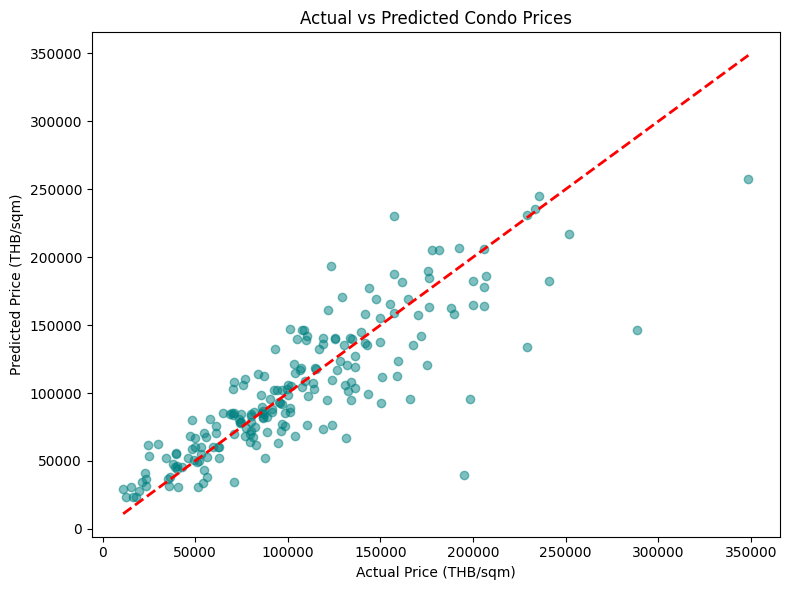

In [28]:
# 1. แปลงค่า y_test และ y_pred กลับเป็นหน่วยราคาปกติ (Inverse Transform)
y_test_actual = pt.inverse_transform(y_test.values.reshape(-1, 1)).flatten()
y_pred_actual = pt.inverse_transform(y_pred_transformed.reshape(-1, 1)).flatten()

# 2. คำนวณ Metrics
mae_val = mae(y_test_actual, y_pred_actual)
mse_val = mse(y_test_actual, y_pred_actual)
rmse_val = np.sqrt(mse_val)
r2_val = r2(y_test_actual, y_pred_actual)

# 3. แสดงผล
print("--- Model Performance base on actual price(Unit: THB/sqm) ---")
print(f"R-Squared (R²): {r2_val:.4f}")
print(f"Mean Absolute Error (MAE): {mae_val:,.2f} บาท")
print(f"Root Mean Squared Error (RMSE): {rmse_val:,.2f} บาท")

# 4. Visualization: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test_actual, y_pred_actual, alpha=0.5, color='teal')
plt.plot([y_test_actual.min(), y_test_actual.max()], [y_test_actual.min(), y_test_actual.max()], 'r--', lw=2)
plt.xlabel('Actual Price (THB/sqm)')
plt.ylabel('Predicted Price (THB/sqm)')
plt.title('Actual vs Predicted Condo Prices')
plt.tight_layout()
plt.show()

# สาเหตุที่ค่า R-Squared (R²) แตกต่างกัน เป็นเพราะเราคำนวณบน 'มาตรวัด' (Scale) ที่ต่างกันครับ:

1. R-Squared Score: 0.7602 (เซลล์ก่อนหน้า): คือประสิทธิภาพเมื่อทำนายค่า price_sqm_transformed (ที่ผ่าน Yeo-Johnson มาแล้ว) ค่านี้จะดูสูงกว่าเพราะข้อมูลถูกปรับให้มีความสมดุลและกระจายตัวแบบปกติ (Normal Distribution) ทำให้โมเดลเรียนรู้ Pattern ได้ง่ายขึ้น

2. R-Squared (R²): 0.7229 (เซลล์ล่าสุด): คือประสิทธิภาพเมื่อเราแปลงผลทำนายกลับมาเป็น 'ราคาบาทต่อตารางเมตรจริงๆ' (Actual Price) ค่านี้คือค่าความแม่นยำที่แท้จริงในโลกของความเป็นจริง ซึ่งมักจะต่ำกว่าค่าที่ได้จากมาตรวัด Transform เล็กน้อยเนื่องจากความผันผวนของราคาจริงในตลาดครับ

สรุปคือ 0.78 คือความแม่นยำทางสถิติของโมเดล ส่วน 0.75 คือความแม่นยำเมื่อนำไปใช้งานจริงครับ

In [29]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# 1. เตรียมรายชื่อ Feature ที่โมเดลต้องการ (15 ฟีเจอร์)
features_list = X.columns.tolist()

# 2. สร้าง Widgets สำหรับรับค่า Input
# ใช้ค่า Median เป็นค่าเริ่มต้นเพื่อให้ผู้ใช้งานกรอกง่ายขึ้น
median_values = X.median()
inputs = {}

style = {'description_width': '180px'}
layout = widgets.Layout(width='450px')

for col in features_list:
    if col == 'district_encoded':
        # สำหรับเขต เราให้เลือกจากชื่อเขต แล้วค่อยแปลงเป็นเลขด้านหลัง
        districts = sorted(district_mapping['district'].unique())
        inputs[col] = widgets.Dropdown(options=districts, value='Watthana', description='เลือกเขต (District):', style=style, layout=layout)
    elif col in ['nbr_buildings', 'nbr_floors', 'units', 'bld_age']:
        inputs[col] = widgets.IntText(value=int(median_values[col]), description=f'{col}:', style=style, layout=layout)
    else:
        inputs[col] = widgets.FloatText(value=round(float(median_values[col]), 3), description=f'{col}:', style=style, layout=layout)

# 3. ปุ่มและ Output
predict_btn = widgets.Button(description="ทำนายราคาคอนโด", button_style='success', icon='calculator', layout=widgets.Layout(margin='20px 0 0 180px', height='40px'))
output = widgets.Output()

def on_click_predict(b):
    with output:
        clear_output()
        # สร้าง DataFrame สำหรับทำนาย
        input_data = pd.DataFrame([median_values], columns=features_list)

        for col in features_list:
            if col == 'district_encoded':
                # ดึงค่า Encoding ของเขตที่เลือกมาใส่
                sel_dist = inputs[col].value
                enc_val = district_mapping[district_mapping['district'] == sel_dist]['target_encoded_value'].values[0]
                input_data[col] = enc_val
            else:
                input_data[col] = inputs[col].value

        # ทำนายผลบน Transformed Scale
        pred_trans = xgb_model.predict(input_data)

        # แปลงกลับเป็นราคาจริง (Inverse Transform)
        final_price = pt.inverse_transform(pred_trans.reshape(-1, 1))[0][0]

        print(f"\n" + "="*40)
        print(f"📍 วิเคราะห์สำหรับเขต: {inputs['district_encoded'].value}")
        print(f"💰 ราคาประเมิน: {final_price:,.2f} บาท / ตร.ม.")
        print("="*40)

predict_btn.on_click(on_click_predict)

# แสดงผล Widget
print("--- แบบฟอร์มกรอกข้อมูลเพื่อพยากรณ์ราคา (กรุงเทพฯ) ---")
display(widgets.VBox(list(inputs.values())), predict_btn, output)

--- แบบฟอร์มกรอกข้อมูลเพื่อพยากรณ์ราคา (กรุงเทพฯ) ---


Button(button_style='success', description='ทำนายราคาคอนโด', icon='calculator', layout=Layout(height='40px', m…

Output()